In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Hücre 2: Veri Yükleme, Genel Bakış ve Temizleme

In [2]:
# Veriyi yükleme
df = pd.read_csv('fifa_eda.csv')

print(f"Orijinal Veri Seti Boyutu: {df.shape[0]} satır, {df.shape[1]} sütun\n")

# Mükerrer satır kontrolü ve temizliği
dup_count = df.duplicated().sum()
print(f"Tekrar eden (mükerrer) satır sayısı: {dup_count}")
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Mükerrer satırlar silindi. Yeni boyut: {df.shape}")

# Genel Özet Tablosu
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_deger": df.isnull().sum(),
    "eksik_deger_yuzdesi": (df.isnull().mean() * 100).round(2)
})
print("\n--- Değişken Özeti ---")
display(ozet)

# Analizde kullanılacak hedef sayısal ve kategorik sütunlar
sayisal_sutunlar = ['Age', 'Overall', 'Potential', 'Value', 'Wage']
kategorik_sutunlar = ['Preferred Foot', 'International Reputation']

# Sadece analiz edilecek temel sayısal sütunların ilk 5 satırı
df[sayisal_sutunlar].head()

Orijinal Veri Seti Boyutu: 18207 satır, 18 sütun

Tekrar eden (mükerrer) satır sayısı: 0

--- Değişken Özeti ---


,dtype,n_unique,eksik_deger,eksik_deger_yuzdesi
ID,int64,18207,0,0.00
Name,object,17194,0,0.00
Age,int64,29,0,0.00
Nationality,object,164,0,0.00
Overall,int64,48,0,0.00
Potential,int64,47,0,0.00
Club,object,651,241,1.32
Value,float64,216,252,1.38
Wage,float64,144,0,0.00
Preferred Foot,object,2,0,0.00


,Age,Overall,Potential,Value,Wage
0,31,94,94,110500.0,565.0
1,33,94,94,77000.0,405.0
2,26,92,93,118500.0,290.0
3,27,91,93,72000.0,260.0
4,27,91,92,102000.0,355.0


Hücre 3: Betimsel İstatistikler ve %95 Güven Aralıkları

In [3]:
def ortalama_guven_araligi(seri, guven=0.95):
    veri = seri.dropna()
    n = len(veri)
    ortalama = veri.mean()
    sem = stats.sem(veri)
    t_kritik = stats.t.ppf((1 + guven) / 2, df=n - 1)
    hata_payi = t_kritik * sem
    return ortalama, ortalama - hata_payi, ortalama + hata_payi

print(f"{'Değişken':25s} {'Ortalama':>12s} {'%95 Alt':>12s} {'%95 Üst':>12s}")
print("-" * 65)
for degisken in sayisal_sutunlar:
    ort, alt, ust = ortalama_guven_araligi(df[degisken])
    print(f"{degisken:25s} {ort:>12.2f} {alt:>12.2f} {ust:>12.2f}")

betimsel = df[sayisal_sutunlar].describe().T
betimsel["skew"] = df[sayisal_sutunlar].skew()
betimsel["kurtosis"] = df[sayisal_sutunlar].kurtosis()
print("\n--- Betimsel İstatistikler (Çarpıklık ve Basıklık Dahil) ---")
display(betimsel.round(2))

Değişken                      Ortalama      %95 Alt      %95 Üst
-----------------------------------------------------------------
Age                              25.12        25.05        25.19
Overall                          66.24        66.14        66.34
Potential                        71.31        71.22        71.40
Value                          2444.53      2362.22      2526.84
Wage                              9.73         9.41        10.05

--- Betimsel İstatistikler (Çarpıklık ve Basıklık Dahil) ---


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,18207.0,25.12,4.67,16.0,21.0,25.0,28.0,45.0,0.39,-0.46
Overall,18207.0,66.24,6.91,46.0,62.0,66.0,71.0,94.0,0.07,0.10
Potential,18207.0,71.31,6.14,48.0,67.0,71.0,75.0,95.0,0.27,0.04
Value,17955.0,2444.53,5626.72,10.0,325.0,700.0,2100.0,118500.0,7.03,76.00
Wage,18207.0,9.73,22.00,0.0,1.0,3.0,9.0,565.0,7.91,100.71


Hücre 4: Normallik Testleri ve Q-Q Grafikleri

Değişken               Shapiro-Wilk p      DAgostino p Yorum
---------------------------------------------------------------------------
Age                            0.0000           0.0000 Normal dağılım sağlanmıyor.
Overall                        0.0000           0.0000 Normal dağılım sağlanmıyor.
Potential                      0.0000           0.0000 Normal dağılım sağlanmıyor.
Value                          0.0000           0.0000 Normal dağılım sağlanmıyor.
Wage                           0.0000           0.0000 Normal dağılım sağlanmıyor.


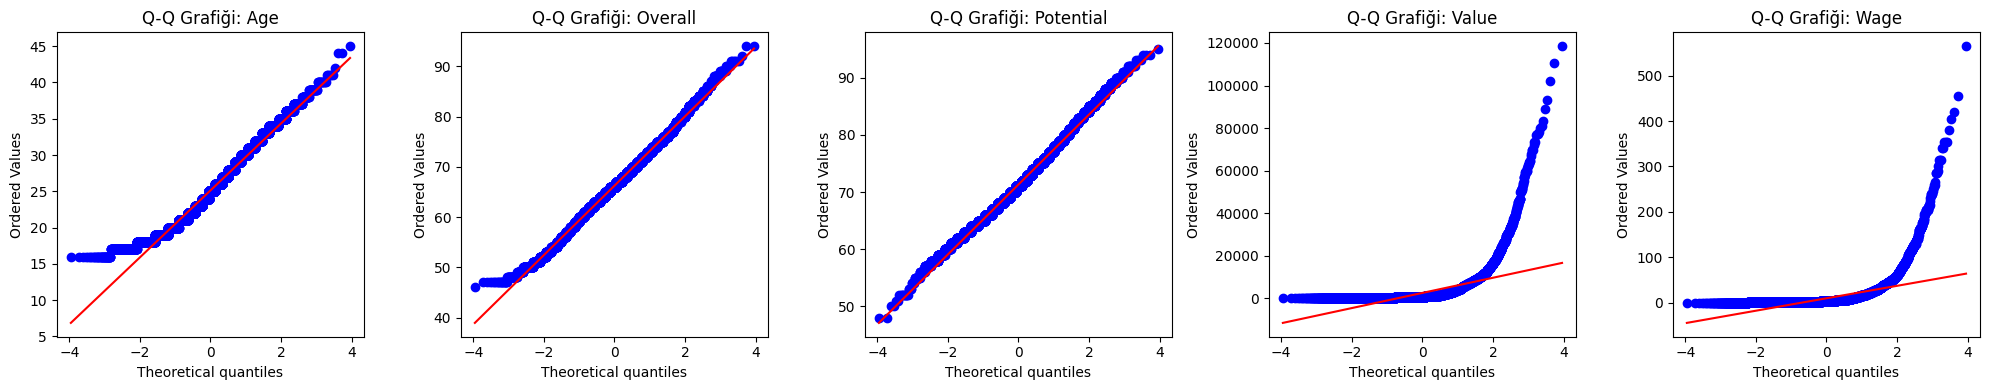

In [4]:
print(f"{'Değişken':20s} {'Shapiro-Wilk p':>16s} {'DAgostino p':>16s} Yorum")
print("-" * 75)
for col in sayisal_sutunlar:
    veri = df[col].dropna()
    # Shapiro-Wilk testinde büyük örneklem sapmasını önlemek için n=5000 sınırı
    ornek = veri.sample(min(len(veri), 5000), random_state=42)
    sw_stat, sw_p = stats.shapiro(ornek)
    da_stat, da_p = stats.normaltest(veri)
    yorum = "Normal dağılım sağlanıyor." if sw_p > 0.05 else "Normal dağılım sağlanmıyor."
    print(f"{col:20s} {sw_p:>16.4f} {da_p:>16.4f} {yorum}")

# Q-Q Grafikleri
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(20, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

Hücre 5: İki Bağımsız Grup Karşılaştırması (Preferred Foot vs Overall)

In [5]:
# Sol ve Sağ ayaklı oyuncuların Overall (Genel Yetenek) puanları
grup_left = df.loc[df["Preferred Foot"] == "Left", "Overall"].dropna()
grup_right = df.loc[df["Preferred Foot"] == "Right", "Overall"].dropna()

# 1. Varyans Homojenliği (Levene)
levene_stat, levene_p = stats.levene(grup_left, grup_right)
print(f"Levene Testi p-değeri: {levene_p:.4f} -> " +
      ("Varyanslar homojendir." if levene_p > 0.05 else "Varyanslar homojen değildir."))

# 2. Grup İçi Normallik Kontrolleri
_, p_left = stats.shapiro(grup_left.sample(min(len(grup_left), 5000), random_state=42))
_, p_right = stats.shapiro(grup_right.sample(min(len(grup_right), 5000), random_state=42))
print(f"Grup Normallik p-değerleri: Sol Ayak -> {p_left:.4f}, Sağ Ayak -> {p_right:.4f}")

# 3. Hipotez Testi (Normallik ihlal edildiği için Mann-Whitney U; sağlansa Bağımsız T-Testi)
if p_left > 0.05 and p_right > 0.05 and levene_p > 0.05:
    t_stat, p_val = stats.ttest_ind(grup_left, grup_right, equal_var=True)
    print(f"\nBağımsız İki Örneklem T-Testi: t = {t_stat:.4f}, p = {p_val:.4f}")
else:
    u_stat, p_val = stats.mannwhitneyu(grup_left, grup_right, alternative='two-sided')
    print(f"\nMann-Whitney U Testi (Non-parametrik): U = {u_stat:.2f}, p = {p_val:.4f}")

print("Sonuç: " + ("Gruplar arasında istatistiksel olarak anlamlı fark VARDIR (p < 0.05)."
                   if p_val < 0.05 else "Gruplar arasında istatistiksel olarak anlamlı fark YOKTUR (p >= 0.05)."))

Levene Testi p-değeri: 0.0000 -> Varyanslar homojen değildir.
Grup Normallik p-değerleri: Sol Ayak -> 0.0000, Sağ Ayak -> 0.0000

Mann-Whitney U Testi (Non-parametrik): U = 31200162.50, p = 0.0000
Sonuç: Gruplar arasında istatistiksel olarak anlamlı fark VARDIR (p < 0.05).


Hücre 6: Çoklu Grup Karşılaştırması (ANOVA, Kruskal-Wallis, Eta-Kare, Tukey HSD)

In [6]:
# 1, 2, 3 ve üzeri olan ana gruplar (yeterli gözleme sahip olanlar)
reputation_groups = [g["Overall"].dropna().values for _, g in df.groupby("International Reputation") if len(g) >= 30]

# Parametrik ANOVA ve Non-parametrik Kruskal-Wallis
f_stat, anova_p = stats.f_oneway(*reputation_groups)
h_stat, kw_p = stats.kruskal(*reputation_groups)

print(f"Tek Yönlü ANOVA: F = {f_stat:.3f}, p = {anova_p:.4e}")
print(f"Kruskal-Wallis:   H = {h_stat:.3f}, p = {kw_p:.4e}")

# Etki Büyüklüğü (Eta-Kare)
genel_ortalama = df["Overall"].mean()
ss_between = sum(len(g) * (g.mean() - genel_ortalama)**2 for g in reputation_groups)
ss_total = sum((df["Overall"].dropna() - genel_ortalama)**2)
eta_kare = ss_between / ss_total
print(f"Eta Kare (η²): {eta_kare:.4f} (0.01 küçük, 0.06 orta, 0.14 büyük etki)")

# Fark anlamlı çıktığı için Post-Hoc Tukey HSD
if anova_p < 0.05:
    print("\n--- Post-Hoc Tukey HSD Testi Sonuçları ---")
    sub_df = df[df["International Reputation"].isin([1.0, 2.0, 3.0, 4.0, 5.0])].dropna(subset=["Overall", "International Reputation"])
    tukey = pairwise_tukeyhsd(endog=sub_df["Overall"], groups=sub_df["International Reputation"], alpha=0.05)
    print(tukey)

Tek Yönlü ANOVA: F = 2048.735, p = 0.0000e+00
Kruskal-Wallis:   H = 3452.698, p = 0.0000e+00
Eta Kare (η²): 0.2517 (0.01 küçük, 0.06 orta, 0.14 büyük etki)

--- Post-Hoc Tukey HSD Testi Sonuçları ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0  10.3768    0.0  9.9014 10.8522   True
   1.0    3.0  16.1463    0.0  15.212 17.0806   True
   1.0    4.0  21.0287    0.0 18.7467 23.3106   True
   1.0    5.0  25.6463    0.0 19.0023 32.2904   True
   2.0    3.0   5.7695    0.0  4.7366  6.8024   True
   2.0    4.0  10.6518    0.0  8.3278 12.9759   True
   2.0    5.0  15.2695    0.0  8.6109 21.9281   True
   3.0    4.0   4.8824    0.0   2.423  7.3417   True
   3.0    5.0      9.5 0.0011   2.793  16.207   True
   4.0    5.0   4.6176 0.3772 -2.4051 11.6404  False
----------------------------------------------------


Hücre 7: Kategorik Değişken İlişkisi (Ki-Kare & Cramér's V)

In [7]:
def cramers_v(x, y):
    tablo = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tablo)[0]
    n = tablo.sum().sum()
    k = min(tablo.shape) - 1
    return np.sqrt(chi2 / (n * k))

# Örnek: Tercih edilen ayak (Left/Right) ile Uluslararası İtibar (Reputation) bağımsızlığı
capraz = pd.crosstab(df["Preferred Foot"], df["International Reputation"])
chi2, p, dof, expected = stats.chi2_contingency(capraz)
v = cramers_v(df["Preferred Foot"].dropna(), df["International Reputation"].dropna())

print(f"Ki-Kare İstatistiği: {chi2:.4f}, p-değeri: {p:.4f}, Serbestlik Derecesi: {dof}")
print(f"Cramer's V: {v:.4f}")
print("\n--- Çapraz Tablo ---")
display(capraz)

Ki-Kare İstatistiği: 1.8687, p-değeri: 0.7599, Serbestlik Derecesi: 4
Cramer's V: 0.0101

--- Çapraz Tablo ---


International Reputation,1.0,2.0,3.0,4.0,5.0
Preferred Foot,,,,,
Left,3839,290,66,15,1
Right,12693,971,243,36,5


Hücre 8: Korelasyon Analizi & Isı Haritası (Heatmap)

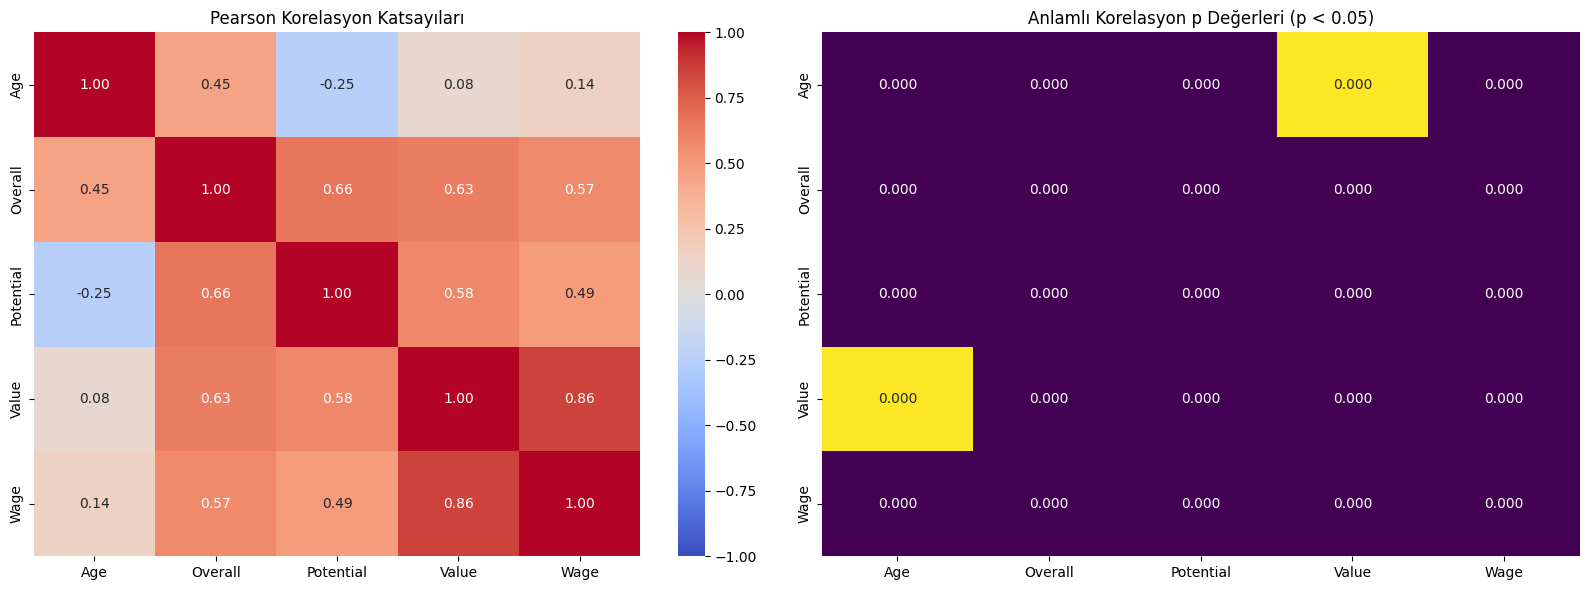

In [8]:
def korelasyon_p_matrisi(veri, yontem="pearson"):
    sutunlar = veri.columns
    kat = pd.DataFrame(np.ones((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
    pval = pd.DataFrame(np.zeros((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
    for i in sutunlar:
        for j in sutunlar:
            if i == j:
                continue
            ortak = veri[[i, j]].dropna()
            r, p = stats.pearsonr(ortak.iloc[:, 0], ortak.iloc[:, 1]) if yontem == "pearson" else stats.spearmanr(ortak.iloc[:, 0], ortak.iloc[:, 1])
            kat.loc[i, j] = float(r)
            pval.loc[i, j] = float(p)
    return kat, pval

corr_r, corr_p = korelasyon_p_matrisi(df[sayisal_sutunlar], yontem="pearson")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_r, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Korelasyon Katsayıları")

# p > 0.05 olan anlamsız korelasyonları maskeleme
anlamsiz_maske = corr_p > 0.05
sns.heatmap(corr_p, annot=True, fmt=".3f", cmap="viridis", mask=anlamsiz_maske, ax=axes[1], cbar=False)
axes[1].set_title("Anlamlı Korelasyon p Değerleri (p < 0.05)")

plt.tight_layout()
plt.show()

Hücre 9: Çoklu Doğrusal Bağlantı (VIF)

In [9]:
# Çoklu bağlantı kontrolü için bağımsız değişkenler
X_vif = df[['Age', 'Potential', 'Value']].dropna()
X_vif_const = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns,
    "VIF": [VIF(X_vif_const.values, i) for i in range(1, X_vif_const.shape[1])]
})
print("--- VIF Değerleri ---")
print(vif_tablosu)

--- VIF Değerleri ---
    Değişken       VIF
0        Age  1.161545
1  Potential  1.738442
2      Value  1.638327


Hücre 10: OLS Çoklu Doğrusal Regresyon Modeli
Maaş (Wage) ve Bonservis (Value) değişkenlerindeki aşırı sağa çarpıklık ve aykırı değerleri dengelemek için logaritmik dönüşüm yapılmıştır.

In [10]:
# Analiz için eksik değerlerden arındırılmış alt küme
reg_data = df[['Overall', 'Age', 'Potential', 'Value', 'Wage']].dropna().copy()

# Aşırı sağa çarpık finansal değişkenlere log1p dönüşümü
reg_data['log_Value'] = np.log1p(reg_data['Value'])
reg_data['log_Wage'] = np.log1p(reg_data['Wage'])

# Model formülü: Oyuncunun Genel Reytingini (Overall) tahmin etme
model = smf.ols(formula="Overall ~ Age + Potential + log_Value + log_Wage", data=reg_data)
sonuc = model.fit()

print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:                Overall   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                 1.859e+05
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:56:08   Log-Likelihood:                -26568.
No. Observations:               17955   AIC:                         5.315e+04
Df Residuals:                   17950   BIC:                         5.319e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.0417      0.181     82.931      0.0

Hücre 11: Temel Bileşenler Analizi (PCA)

Bileşenlerin Açıkladığı Varyans Oranları:
PC1: %58.62 (Kümülatif: %58.62)
PC2: %24.92 (Kümülatif: %83.54)
PC3: %12.48 (Kümülatif: %96.02)
PC4: %2.70 (Kümülatif: %98.72)
PC5: %1.28 (Kümülatif: %100.00)


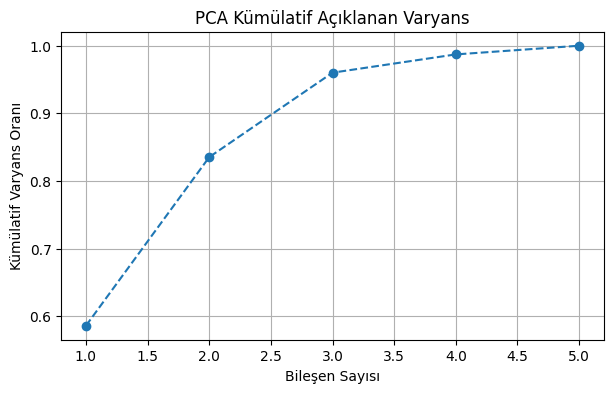

In [11]:
pca_verisi = df[sayisal_sutunlar].dropna()

# Ölçeklendirme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
aciklanan_varyans = pca.explained_variance_ratio_

print("Bileşenlerin Açıkladığı Varyans Oranları:")
for i, var in enumerate(aciklanan_varyans, start=1):
    print(f"PC{i}: %{var*100:.2f} (Kümülatif: %{aciklanan_varyans[:i].sum()*100:.2f})")

# Kümülatif Varyans Grafiği
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(aciklanan_varyans) + 1), np.cumsum(aciklanan_varyans), marker='o', linestyle='--')
plt.title('PCA Kümülatif Açıklanan Varyans')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Varyans Oranı')
plt.grid(True)
plt.show()